In [1]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

In [3]:
# ============================================================
# KRITERIA 1: Memuat Dataset dan EDA
# ============================================================
df = pd.read_csv('fraud_dataset.csv')
df.head()

,TransactionID,AccountID,DeviceID,IPAddress,MerchantID,TransactionDate,Amount,TransactionType,Channel,CustomerAge,CustomerGender,LoginAttempts,AccountBalance,TransactionDuration,IsFraud
0,TXN000001,ACC8270,DEV498,1.238.150.121,MER55,2024-01-01 00:00:00,90.90,Payment,POS,53.0,Male,2,23288.00,95.0,0
1,TXN000002,ACC1860,DEV310,167.252.125.56,MER73,2024-01-01 00:30:00,35.22,Withdrawal,ATM,32.0,Female,2,39528.69,253.0,0
2,TXN000003,ACC6390,DEV490,81.161.250.168,MER55,2024-01-01 01:00:00,0.56,Withdrawal,Mobile,36.0,Female,1,27228.84,136.0,0
3,TXN000004,ACC6191,DEV598,221.72.140.69,MER65,2024-01-01 01:30:00,41.46,Payment,Web,68.0,Male,2,98449.40,173.0,0
4,TXN000005,ACC6734,DEV639,6.83.51.244,MER53,2024-01-01 02:00:00,106.92,Withdrawal,Mobile,59.0,Female,2,85492.55,64.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        2050 non-null   str    
 1   AccountID            2050 non-null   str    
 2   DeviceID             2050 non-null   str    
 3   IPAddress            2050 non-null   str    
 4   MerchantID           2050 non-null   str    
 5   TransactionDate      2050 non-null   str    
 6   Amount               2050 non-null   float64
 7   TransactionType      2050 non-null   str    
 8   Channel              2050 non-null   str    
 9   CustomerAge          2019 non-null   float64
 10  CustomerGender       2050 non-null   str    
 11  LoginAttempts        2050 non-null   int64  
 12  AccountBalance       2019 non-null   float64
 13  TransactionDuration  2020 non-null   float64
 14  IsFraud              2050 non-null   int64  
dtypes: float64(4), int64(2), str(9)
memory usage: 240

In [5]:
df.describe()

,Amount,CustomerAge,LoginAttempts,AccountBalance,TransactionDuration,IsFraud
count,2050.000000,2019.000000,2050.000000,2019.000000,2020.000000,2050.000000
mean,145.432341,46.198613,2.433659,49287.320505,152.929703,0.156585
std,143.810508,16.759704,1.427861,28022.265156,86.153985,0.363498
min,0.010000,18.000000,1.000000,517.460000,5.000000,0.000000
25%,43.697500,32.000000,1.000000,25542.140000,79.000000,0.000000
50%,102.090000,46.000000,2.000000,48934.550000,151.000000,0.000000
75%,198.137500,61.000000,4.000000,72008.275000,229.000000,0.000000
max,1141.700000,74.000000,5.000000,99737.940000,299.000000,1.000000


In [6]:
# ============================================================
# KRITERIA 2: Pembersihan dan Pra Pemrosesan Data
# ============================================================
print("Missing Values:")
print(df.isnull().sum())
print(f"\nData Duplikat: {df.duplicated().sum()}")

Missing Values:
TransactionID           0
AccountID               0
DeviceID                0
IPAddress               0
MerchantID              0
TransactionDate         0
Amount                  0
TransactionType         0
Channel                 0
CustomerAge            31
CustomerGender          0
LoginAttempts           0
AccountBalance         31
TransactionDuration    30
IsFraud                 0
dtype: int64

Data Duplikat: 50


In [7]:
df = df.dropna()
df = df.drop_duplicates()
print(f"Data setelah cleaning: {df.shape}")

# Drop kolom ID, Address, Date
df = df.drop(columns=['TransactionID', 'AccountID', 'DeviceID',
                       'IPAddress', 'MerchantID', 'TransactionDate'])

# Label Encoding
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

print(f"Kolom: {list(df.columns)}")
df.head()

Data setelah cleaning: (1911, 15)
Kolom: ['Amount', 'TransactionType', 'Channel', 'CustomerAge', 'CustomerGender', 'LoginAttempts', 'AccountBalance', 'TransactionDuration', 'IsFraud']


,Amount,TransactionType,Channel,CustomerAge,CustomerGender,LoginAttempts,AccountBalance,TransactionDuration,IsFraud
0,90.90,1,2,53.0,1,2,23288.00,95.0,0
1,35.22,3,0,32.0,0,2,39528.69,253.0,0
2,0.56,3,1,36.0,0,1,27228.84,136.0,0
3,41.46,1,3,68.0,1,2,98449.40,173.0,0
4,106.92,3,1,59.0,0,2,85492.55,64.0,0


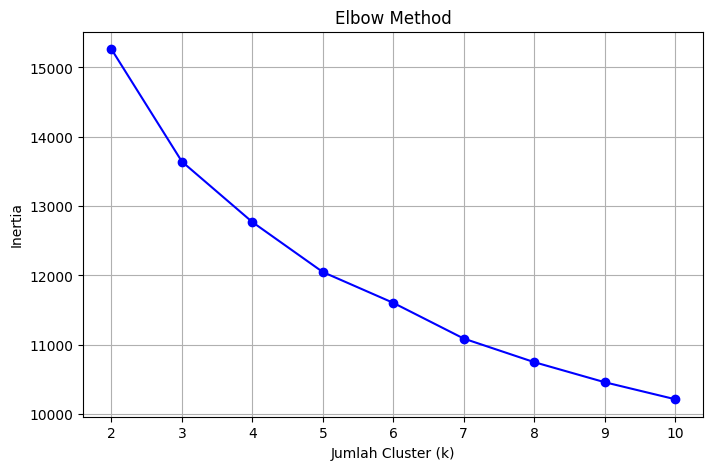

Cluster optimal: 4


In [8]:
# ============================================================
# KRITERIA 3: Membangun Model Clustering
# ============================================================
df_clustering = df.copy()
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)

# Elbow Method
inertias = []
K = range(2, 11)
for k in K:
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(df_scaled).inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K)
plt.grid(True)
plt.show()

optimal_k = list(K)[np.argmax(np.diff(np.diff(inertias))) + 2]
print(f"Cluster optimal: {optimal_k}")

In [9]:
# K-Means Clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans.fit_predict(df_scaled)
print(df_clustering['Cluster'].value_counts().sort_index())

Cluster
0    719
1    210
2    686
3    296
Name: count, dtype: int64


In [10]:
# Simpan model clustering
joblib.dump(kmeans, 'model_clustering.h5')

['model_clustering.h5']

In [11]:
# ============================================================
# KRITERIA 4: Interpretasi Hasil Clustering
# ============================================================
num_cols = [c for c in df_clustering.columns if c != 'Cluster']

# Analisis deskriptif mean, min, max
print("=== Analisis Deskriptif ===")
print(df_clustering[num_cols].agg(['mean', 'min', 'max']))

# Karakteristik tiap cluster
print("\n=== Mean per Cluster ===")
print(df_clustering.groupby('Cluster')[num_cols].mean())

print("\n=== Min per Cluster ===")
print(df_clustering.groupby('Cluster')[num_cols].min())

print("\n=== Max per Cluster ===")
print(df_clustering.groupby('Cluster')[num_cols].max())

=== Analisis Deskriptif ===
           Amount  TransactionType   Channel  CustomerAge  CustomerGender  \
mean   145.962083         1.492412  1.485086    46.287284        0.508111   
min      0.010000         0.000000  0.000000    18.000000        0.000000   
max   1141.700000         3.000000  3.000000    74.000000        1.000000   

      LoginAttempts  AccountBalance  TransactionDuration   IsFraud  
mean         2.4427    49096.131491           153.791209  0.156463  
min          1.0000      517.460000             5.000000  0.000000  
max          5.0000    99737.940000           299.000000  1.000000  

=== Mean per Cluster ===
             Amount  TransactionType   Channel  CustomerAge  CustomerGender  \
Cluster                                                                       
0        106.454033         1.492350  1.475661    46.212796        0.000000   
1        452.660286         1.590476  1.504762    46.466667        0.657143   
2        100.762755         1.472303  1.48105

In [12]:
# Ekspor data + kolom Target
df_export = df_clustering.rename(columns={'Cluster': 'Target'})
df_export.to_csv('data_clustering.csv', index=False)
print(f"✅ data_clustering.csv ({len(df_export)} rows)")
df_export.head()

✅ data_clustering.csv (1911 rows)


,Amount,TransactionType,Channel,CustomerAge,CustomerGender,LoginAttempts,AccountBalance,TransactionDuration,IsFraud,Target
0,90.90,1,2,53.0,1,2,23288.00,95.0,0,2
1,35.22,3,0,32.0,0,2,39528.69,253.0,0,0
2,0.56,3,1,36.0,0,1,27228.84,136.0,0,0
3,41.46,1,3,68.0,1,2,98449.40,173.0,0,2
4,106.92,3,1,59.0,0,2,85492.55,64.0,0,0
